In [9]:
from plot import *
import numpy as np
import math
import matplotlib.pyplot as plt

In [1]:
T = 100  # number of time steps

# Resource indices
F_idx, U_idx, O_idx, E_idx = 0, 1, 2, 3
n_res = 4

# --- Population and workers ---
P0 = 5               # initial population
rescue_interval = 60  # steps between refugee waves
deltaP = 5            # population increase per wave
worker_fraction = 0.7 # fraction of population that works

# Job fractions (sum to 1.0)
f_hunt   = 0.3
f_mine   = 0.2
f_stoke  = 0.2
f_lumber = 0.3  # 1 - f_hunt - f_mine - f_stoke

# --- Production yields per worker per step ---
sF_hunt   = 20.0  # food
sU_lumber = 1.525  # fuel
sO_mine   = 1.01  # ore

# --- Player food supply ---
player_supply_interval = 3    # 玩家每多少天补充一次食物
player_supply_amount = 300    # 玩家每次补充的饱食度

# --- Fuel->Energy conversion ---
burn_capacity_per_worker = 1.0  # max fuel burned per stoker per step
eta = 5.0                       # energy per unit fuel burned

# --- Resident demands ---
dF_res    = 7.5  # food per person per step
dO_infra  = 0.14  # ore per person per step (infra upkeep)

# --- Temperature / weather ---
T_comfort     = 20.0
heat_per_person_per_degree = 0.05  # energy per person per degree below comfort

# --- Initial stocks ---
R_F = 5000.0  # food
R_U = 1000.0  # fuel
R_O = 1000.0  # ore
R_E = 1000.0    # energy

# History arrays
R_hist       = np.zeros((T, n_res))
S_hist       = np.zeros((T, n_res))
D_hist       = np.zeros((T, n_res))
balance_hist = np.zeros((T, n_res))
phi_hist     = np.zeros(T)
P_hist       = np.zeros(T)
Tout_hist    = np.zeros(T)

eps = 1e-6

NameError: name 'np' is not defined

In [ ]:
import numpy as np

def generate_temperature_series(
    T=300,
    T_mean=-10.0,
    T_amp=10.0,
    T_period=80.0,
    T_noise_sigma=3.0,
    # event system params
    event_probs={"cold": 0.15, "heat": 0.10, "normal": 0.75},
    event_duration_mu=30, event_duration_sigma=10,
    cold_mu=-8.0, cold_sigma=3.0,
    heat_mu=+8.0, heat_sigma=3.0,
    seed=0
):
    """
    Generate temperature series with:
    - seasonal cycle,
    - gaussian weather noise,
    - multi-step cold/heat/normal events.
    """
    rng = np.random.default_rng(seed)
    temps = np.zeros(T)

    event_type = np.empty(T, dtype=object)
    event_delta = np.zeros(T)

    t = 0
    # Generate events
    while t < T:
        etype = rng.choice(["cold", "heat", "normal"], p=[
            event_probs["cold"],
            event_probs["heat"],
            event_probs["normal"]
        ])
        duration = int(rng.normal(event_duration_mu, event_duration_sigma))
        duration = min(duration, T - t)

        # Fill event type
        event_type[t:t+duration] = etype

        # Draw shift for the whole event block
        if etype == "cold":
            shift = rng.normal(cold_mu, cold_sigma)
        elif etype == "heat":
            shift = rng.normal(heat_mu, heat_sigma)
        else:
            shift = 0.0
        event_delta[t:t+duration] = shift

        t += duration

    # Create final temp series
    for step in range(T):
        seasonal = T_mean + T_amp * np.sin(2 * np.pi * step / T_period)
        noise = rng.normal(0.0, T_noise_sigma)
        temps[step] = seasonal + noise + event_delta[step]

    return temps, event_type, event_delta

# # Run the generator + print preview
# temps, event_type, deltas = generate_temperature_series(T=60)
# temps[:10], event_type[:10], deltas[:10]


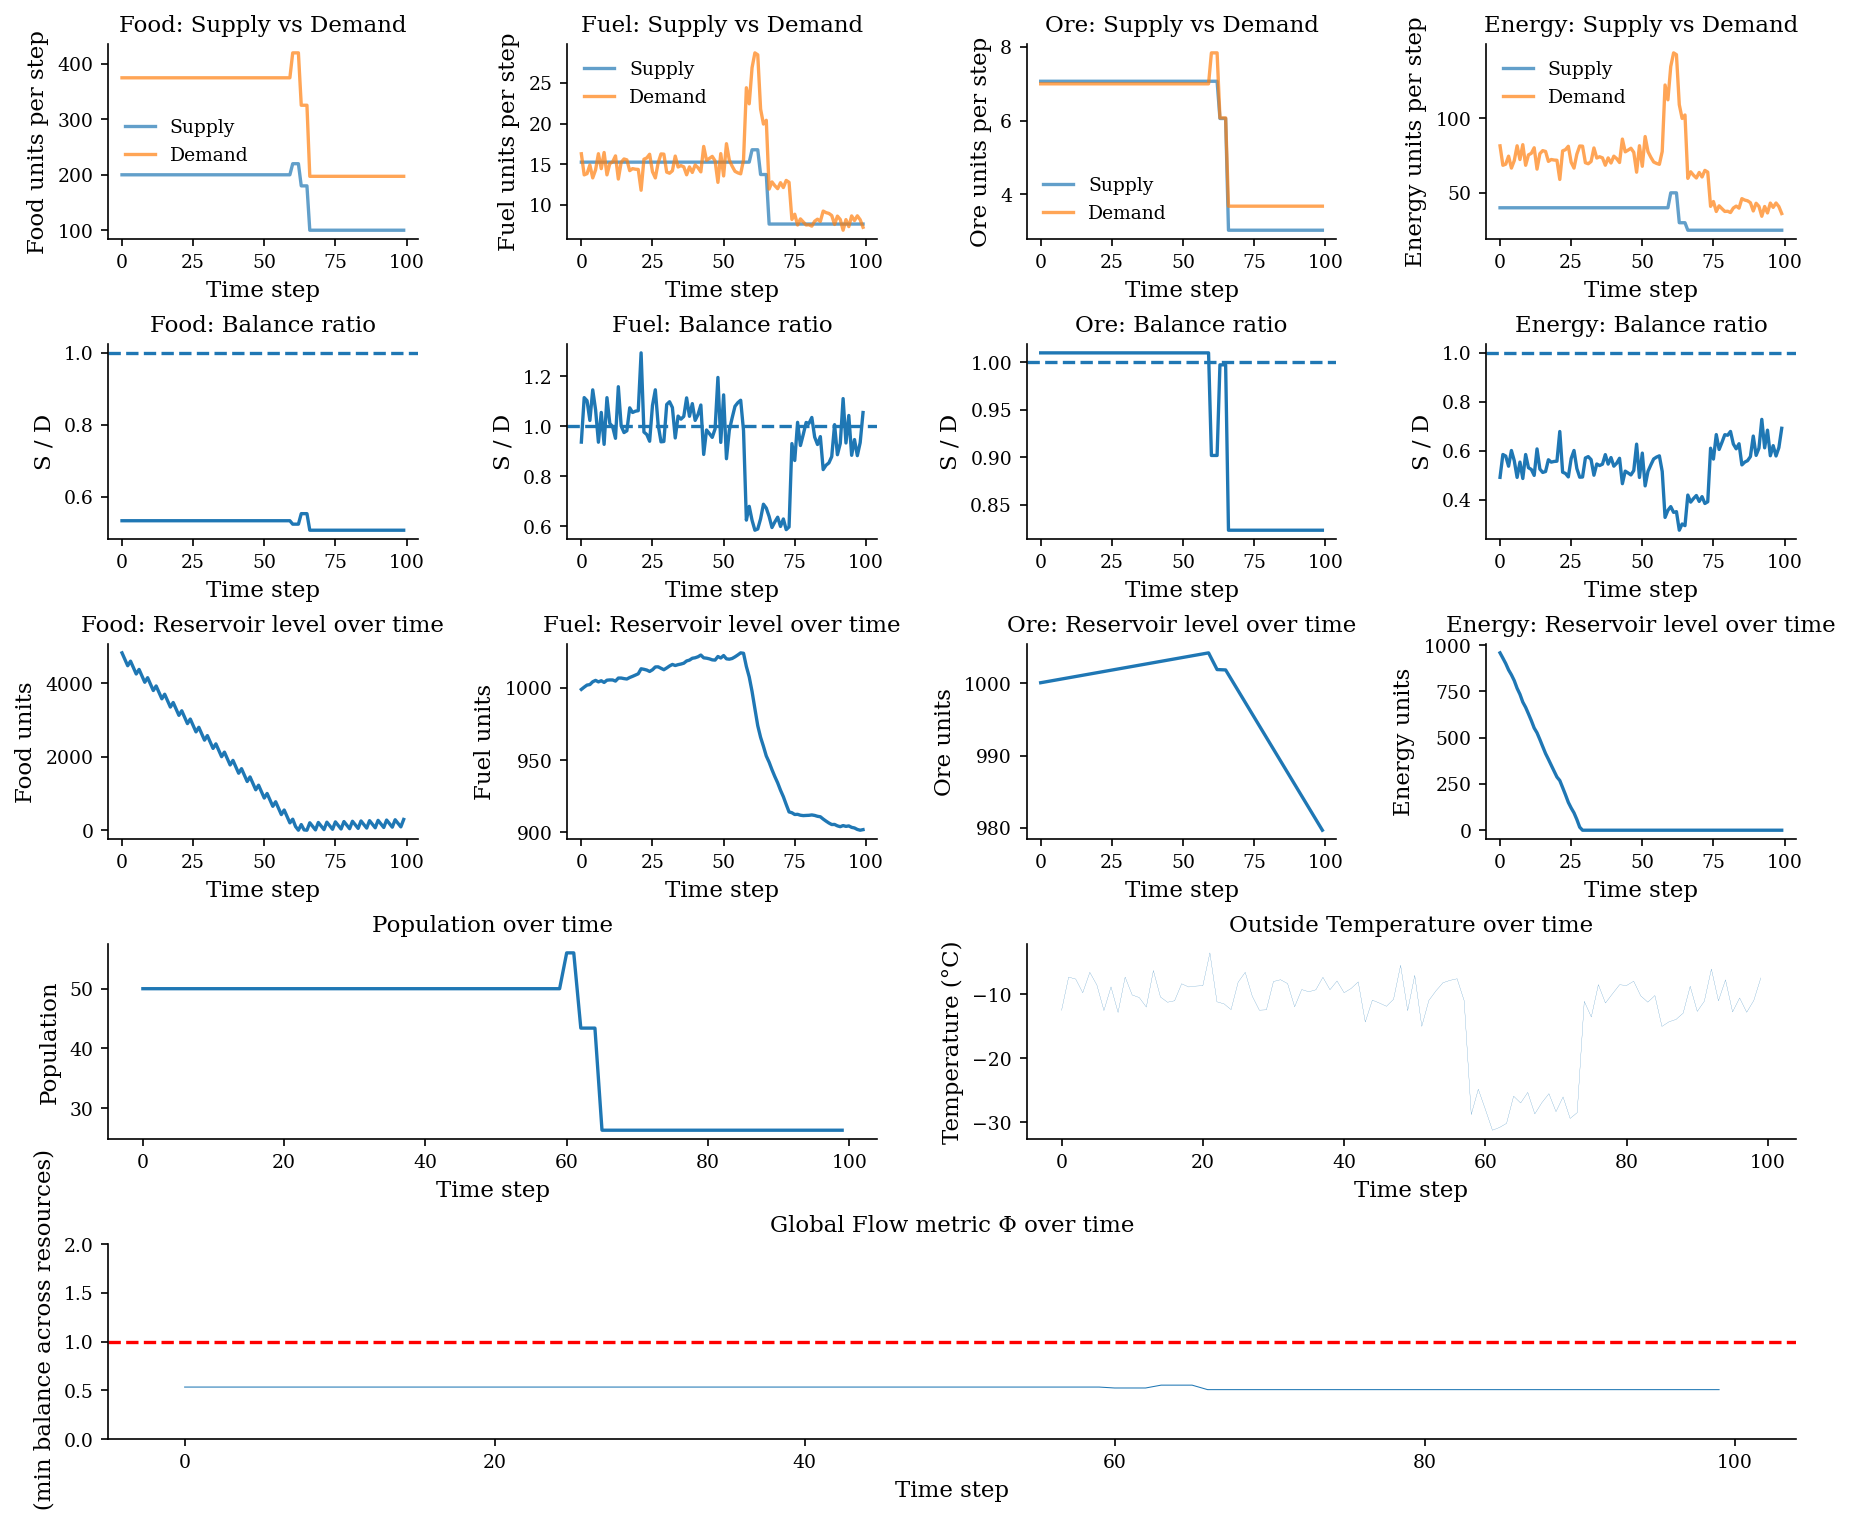

In [12]:
Tout_hist, _, _ = generate_temperature_series(
    T= T,
    T_mean        = -10.0,  # average outside temp
    T_amp         = 0.0,   # seasonal amplitude
    T_period      = 365.0,   # steps per full temp cycle
    T_noise_sigma = 3.0,    # weather randomness
    seed=42,
    # event system params
    event_probs={"cold": 0.1, "heat": 0.1, "normal": 0.8},
    event_duration_mu=30, event_duration_sigma=10,
    cold_mu=-20.0, cold_sigma=20.0,
    heat_mu=+5.0, heat_sigma=3.0
)

P = P0
for t in range(T):
    # Stochastic population arrivals
    if t % rescue_interval == 0 and t > 0:
        P += np.random.poisson(deltaP)
    # Large waves every 10 * rescue_interval steps
    if t % (10 * rescue_interval) == 0 and t > 0:
        P += np.random.poisson(10 * deltaP)
    
    
    workers_total = int(P * worker_fraction)
    w_hunt   = int(workers_total * f_hunt)
    w_lumber = int(workers_total * f_lumber)
    w_mine   = int(workers_total * f_mine)
    w_stoke  = workers_total - w_hunt - w_lumber - w_mine  # remainder
    
    T_out = Tout_hist[t]
    
    # --- Demands ---
    # Food
    D_F = P * dF_res
    
    # Ore (infrastructure)
    D_O = P * dO_infra
    
    # Energy for heating
    temp_diff   = max(1.0, T_comfort - T_out)
    D_E_heat    = P * heat_per_person_per_degree * temp_diff
    D_E         = D_E_heat  # in this toy model, energy is only used for heat
    
    # --- Supplies from labor (food, fuel, ore) ---
    S_F = w_hunt   * sF_hunt
    S_U = w_lumber * sU_lumber
    S_O = w_mine   * sO_mine
    
    # --- Decide fuel burn for energy ---
    fuel_needed_for_heat   = D_E_heat / eta if eta > 0 else 0.0
    
    # Population will decline if F, U, or O are insufficient for demands even after stockpiles

    # --- 玩家定时补充食物 ---
    if t > 0 and t % player_supply_interval == 0:
        R_F += player_supply_amount

    # Food shortage
    P_loss_total = 0.0
    if R_F + S_F < D_F:
        P_deficit = D_F - (R_F + S_F)
        P_food_loss_prob = 0.9
        P_loss = math.ceil(P_deficit / dF_res) * P_food_loss_prob
        P_loss_total += P_loss
    # Ore shortage
    if R_O + S_O < D_O:
        P_deficit = D_O - (R_O + S_O)
        P_ore_loss_prob = 0.1
        P_loss = math.ceil(P_deficit / dO_infra) * P_ore_loss_prob
        P_loss_total += P_loss
    # Fuel shortage (leading to energy shortage)
    if R_U + S_U < fuel_needed_for_heat:
        P_deficit = fuel_needed_for_heat - (R_U + S_U)
        P_fuel_loss_prob = 0.9
        P_loss = math.ceil(P_deficit / (burn_capacity_per_worker * eta / heat_per_person_per_degree / max(1.0, T_comfort - T_out))) * P_fuel_loss_prob
        P_loss_total += P_loss
    # Update population
    # if P_loss_total > 0:
    #     print(f"Population loss at step {t}: {P_loss_total}")
    P = max(0, P - P_loss_total)
    P_hist[t] = P
    
    max_fuel_from_workers  = w_stoke * burn_capacity_per_worker
    D_U_burn = fuel_needed_for_heat          # fuel demand
    fuel_burn = min(R_U, max_fuel_from_workers, fuel_needed_for_heat)
    S_E      = eta * fuel_burn    # energy supply
    
    # --- Record S, D ---
    S_hist[t, F_idx] = S_F
    S_hist[t, U_idx] = S_U
    S_hist[t, O_idx] = S_O
    S_hist[t, E_idx] = S_E
    
    D_hist[t, F_idx] = D_F
    D_hist[t, U_idx] = D_U_burn
    D_hist[t, O_idx] = D_O
    D_hist[t, E_idx] = D_E


    # --- Update stockpiles ---
    R_F = max(0.0, R_F + S_F - D_F)
    R_U = max(0.0, R_U + S_U - D_U_burn)
    R_O = max(0.0, R_O + S_O - D_O)
    R_E = max(0.0, R_E + S_E - D_E)
    
    R_hist[t, F_idx] = R_F
    R_hist[t, U_idx] = R_U
    R_hist[t, O_idx] = R_O
    R_hist[t, E_idx] = R_E
    
    # --- Balance and global Flow Φ ---
    balances = S_hist[t] / np.maximum(D_hist[t], eps)
    balance_hist[t] = balances
    # Exclude Energy from calculation of Φ
    balances = balances[[F_idx, U_idx, O_idx]]
    # set phi as the balance with max deviation from 1
    # choose the index with max deviation from 1.0
    max_dev_idx = np.argmax(np.abs(balances - 1.0))
    phi_hist[t] = balances[max_dev_idx]
    
set_style()
# Resources and their names
resources = ["Food", "Fuel", "Ore", "Energy"]
# Create these plots using GridSpec as subplots
import matplotlib.gridspec as gridspec
fig = plt.figure(constrained_layout=True, figsize=(12, 10))
gs = gridspec.GridSpec(5, 4, figure=fig)
# 1) Supply vs Demand for each resource
for i, name in enumerate(resources):
    ax = fig.add_subplot(gs[0, i])
    ax.plot(S_hist[:, i], label="Supply", alpha=0.7)
    ax.plot(D_hist[:, i], label="Demand", alpha=0.7)
    ax.set_xlabel("Time step")
    ax.set_ylabel(f"{name} units per step")
    ax.set_title(f"{name}: Supply vs Demand")
    ax.legend()
# 2) Balance (S/D) for each resource
for i, name in enumerate(resources):
    ax = fig.add_subplot(gs[1, i])
    ax.plot(balance_hist[:, i])
    ax.axhline(1.0, linestyle="--")
    ax.set_xlabel("Time step")
    ax.set_ylabel("S / D")
    ax.set_title(f"{name}: Balance ratio")
# Reservoir levels over time on the next row
for i, name in enumerate(resources):
    ax = fig.add_subplot(gs[2, i])
    ax.plot(R_hist[:, i])
    ax.set_xlabel("Time step")
    ax.set_ylabel(f"{name} units")
    ax.set_title(f"{name}: Reservoir level over time")
# Population over time
ax = fig.add_subplot(gs[3, 0:2])
ax.plot(P_hist)
ax.set_xlabel("Time step")
ax.set_ylabel("Population")
ax.set_title("Population over time")
# Temperature over time
ax = fig.add_subplot(gs[3, 2:4])
ax.plot(Tout_hist, linewidth=0.1)
ax.set_xlabel("Time step")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Outside Temperature over time")
# Global Flow metric Φ(t)
ax = fig.add_subplot(gs[4, :])
ax.plot(phi_hist, linewidth=0.5)
ax.axhline(1.0, linestyle="--", color="red")
ax.set_xlabel("Time step")
ax.set_ylabel("Φ (min balance across resources)")
ax.set_title("Global Flow metric Φ over time")
ax.set_ylim(0.0, 2.0)

plt.savefig("town_simulation_results.png", dpi=300)
plt.show()
